### Normalizing Flow 

This notebook will experiment with multiple aspects of Normalizing Flow related stuffs like:

1. Generate half-moon distribution - NICE will be used to do it. 
2. Sample from a distribution knowing its pdf.
3. Recentering techique will be applied for sampling process  

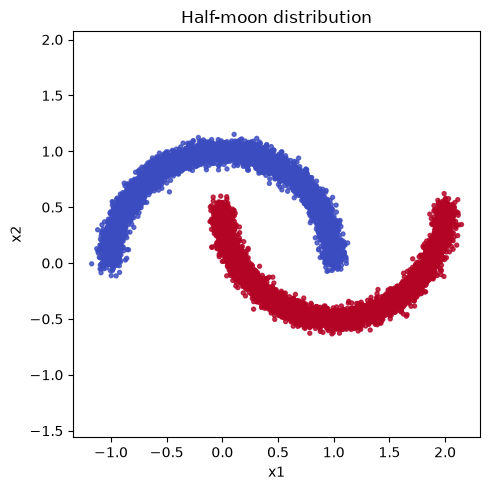

X shape: (10000, 2), y shape: (10000,)


In [30]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 10000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.8)
plt.title("Half-moon distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}, y shape: {y.shape}")

### Recentering

Whiten the data to mean $0$ and covariance $I$ before training NICE:

$$
\tilde{x} = K^{-1}(x - \mu),\qquad \Sigma = KK^\top
$$

We take $K = L$ from the Cholesky factor $\Sigma = LL^\top$. Stats $(\mu, K)$ are estimated once on the full training set and then frozen. To map samples back:

$$
x = \mu + K\,\tilde{x}
$$

mu: [0.50057444 0.24972914]
Sigma:
 [[ 0.75237977 -0.19232314]
 [-0.19232314  0.24610214]]
cov(X_white) ≈
 [[1.00000000e+00 2.64253954e-16]
 [2.64253954e-16 1.00000000e+00]]
mean(X_white): [4.51194637e-16 3.81177312e-15]


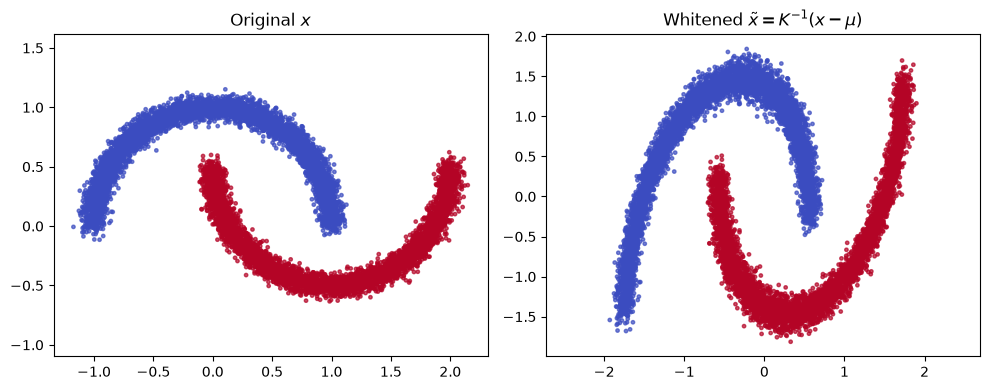

In [31]:
import numpy as np
from numpy.linalg import cholesky, solve

# --- estimate mean & covariance on all training data ---
mu = X.mean(axis=0)
Xc = X - mu
Sigma = (Xc.T @ Xc) / (X.shape[0] - 1)

# K = L with Sigma = L L^T
K = cholesky(Sigma)
K_inv = solve(K, np.eye(K.shape[0]))  # K^{-1}

X_white = (Xc @ K_inv.T)  # equivalent to (K^{-1} (x-mu)^T)^T

print("mu:", mu)
print("Sigma:\n", Sigma)
print("cov(X_white) ≈\n", np.cov(X_white.T))
print("mean(X_white):", X_white.mean(axis=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=y, s=6, cmap="coolwarm", alpha=0.7)
axes[0].set_title("Original $x$")
axes[0].axis("equal")
axes[1].scatter(X_white[:, 0], X_white[:, 1], c=y, s=6, cmap="coolwarm", alpha=0.7)
axes[1].set_title(r"Whitened $\tilde{x} = K^{-1}(x-\mu)$")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

### Train NICE on half-moon

Train on **whitened** data $\tilde{x}$ from the Recentering section.

Couplings have $\det=1$; learnable diagonal scaling contributes $\sum_i (\log s)_i$:

$$
\mathcal{L}(\theta)
= \mathbb{E}_{\tilde{x}}\Big[\tfrac{1}{2}\|f_\theta(\tilde{x})\|^2 - \sum_i (\log s)_i\Big]
$$

Train so latents look like $\mathcal{N}(0,I)$ while fitting volume via $\log s$.

In [32]:
import runpy
from pathlib import Path

import jax
import jax.numpy as jnp
import optax
from jax import random
from tqdm import trange

# project root on sys.path
_root = Path.cwd() if (Path.cwd() / "libs").is_dir() else Path.cwd().parent
runpy.run_path(str(_root / "setup_path.py"), run_name="__setup_path__")

from libs.nice_scratch import NICE

# --- data / model (whitened) ---
X_train = jnp.asarray(X_white, dtype=jnp.float32)
model = NICE(layer_size=2, no_layers=4, hidden_sizes=(64, 64))

key = random.PRNGKey(0)
key, k_init = random.split(key)
variables = model.init(k_init, X_train[:8])
params = variables["params"]

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

def loss_fn(params, batch):
    z, log_det = model.apply({"params": params}, batch)
    # log_det = sum(log s); same for every sample in the batch
    return 0.5 * jnp.mean(jnp.sum(z**2, axis=-1)) - log_det

@jax.jit
def train_step(params, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# --- 1000 epochs ---
n_epochs = 1000
batch_size = 128
losses = []

for epoch in trange(n_epochs, desc="NICE train"):
    key, k_perm = random.split(key)
    perm = random.permutation(k_perm, X_train.shape[0])
    X_shuf = X_train[perm]

    batch_losses = []
    # training with batch-SGD
    for start in range(0, X_train.shape[0], batch_size):
        batch = X_shuf[start : start + batch_size]
        params, opt_state, loss = train_step(params, opt_state, batch)
        batch_losses.append(loss)

    epoch_loss = float(jnp.mean(jnp.stack(batch_losses)))
    losses.append(epoch_loss)
    if epoch % 100 == 0:
        print("loss after {} epoch = {}".format(epoch, epoch_loss))

print(f"final loss: {losses[-1]:.4f} (start {losses[0]:.4f})")

NICE tra

loss after 0 epoch = 0.9812033176422119


NICE tra

loss after 100 epoch = -0.25377780199050903


NICE tra

...

loss after 800 epoch = -0.36831027269363403


NICE tra

loss after 900 epoch = -0.3641678988933563


NICE tra

final loss: -0.3216 (start 0.9812)


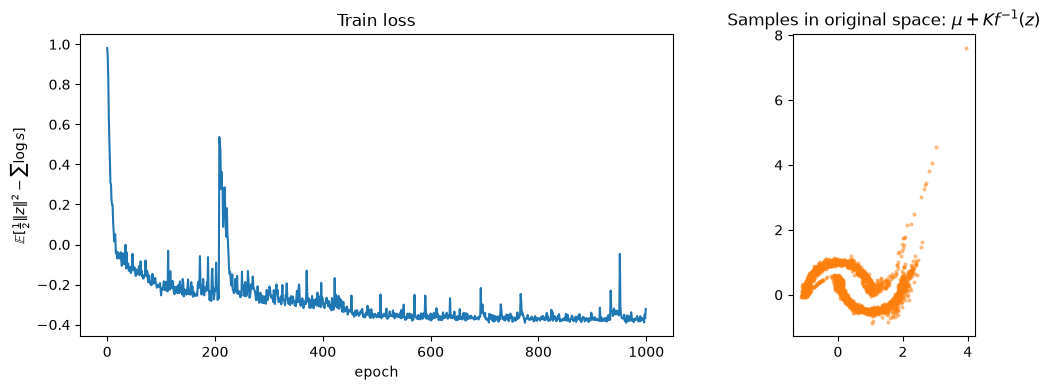

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel(r"$\mathbb{E}[\frac{1}{2}\|z\|^2 - \sum \log s]$")

key, k_samp = random.split(key)
z_prior = random.normal(k_samp, (3000, 2))
x_white_gen, _ = model.apply({"params": params}, z_prior, reverse=True)

# invert recentering: x = mu + K @ x_tilde
x_gen = mu + np.asarray(x_white_gen) @ K.T

axes[1].scatter(x_gen[:, 0], x_gen[:, 1], s=4, alpha=0.4, c="tab:orange")
axes[1].set_title(r"Samples in original space: $\mu + K f^{-1}(z)$")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

### Sampling

Declare a **hard-to-sample** 1D target: equal mixture of two unit-variance Gaussians far apart:

$$
\pi(x) = \tfrac12\,\mathcal{N}(x; 5, 1) + \tfrac12\,\mathcal{N}(x; -5, 1)
$$

(Here $\mathcal{N}(\mu,\sigma^2)$ with $\sigma^2=1$.) Large gap around $0$ makes local MCMC mode-sticky.

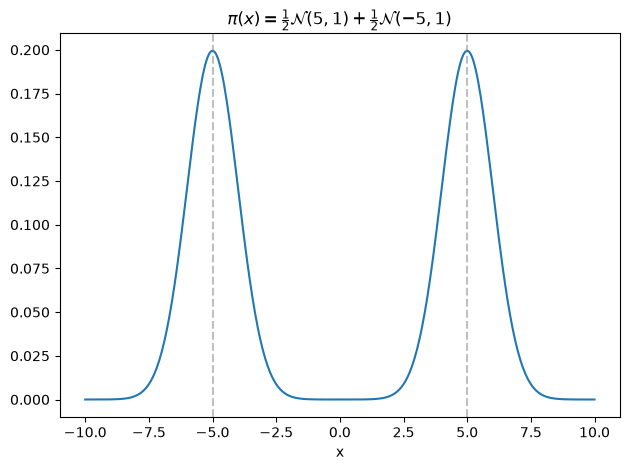

In [5]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
from jax.scipy.stats import norm
from matplotlib import pyplot as plt 
import numpy as np

# --- π(x) = 0.5 N(5, 1) + 0.5 N(-5, 1)  (variance = 1) ---
mix_weights = jnp.array([0.5, 0.5])
mix_means = jnp.array([5.0, -5.0])
mix_vars = jnp.array([1.0, 1.0])  # σ²
mix_scales = jnp.sqrt(mix_vars)   # σ for jax.scipy.stats.norm

def mixture_log_pdf(x):
    """log π(x) for scalar or array x."""
    x = jnp.asarray(x)
    log_comps = jnp.stack([
        norm.logpdf(x, loc=mix_means[k], scale=mix_scales[k]) + jnp.log(mix_weights[k])
        for k in range(mix_weights.shape[0])
    ], axis=0)
    return logsumexp(log_comps, axis=0)

def mixture_pdf(x):
    return jnp.exp(mixture_log_pdf(x))

# --- visualize density ---
xg = jnp.linspace(-10, 10, 400)
density = mixture_pdf(xg)

fig, ax = plt.subplots()
ax.plot(np.asarray(xg), np.asarray(density), color="tab:blue")
ax.axvline(5, color="gray", ls="--", alpha=0.5)
ax.axvline(-5, color="gray", ls="--", alpha=0.5)
ax.set_title(r"$\pi(x)=\frac{1}{2}\mathcal{N}(5,1)+\frac{1}{2}\mathcal{N}(-5,1)$")
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

#### Reverse KL with 2D NICE (lifted target)

Lift the 1D mixture with a dummy Gaussian coordinate so we can reuse 2D NICE:

$$
\pi(x_1,x_2)=\Big(\tfrac12\mathcal{N}(x_1;5,1)+\tfrac12\mathcal{N}(x_1;-5,1)\Big)\,\mathcal{N}(x_2;0,1).
$$

Flow $x=g_\theta(z)$, $z\sim\mathcal{N}(0,I)$. Minimize **reverse KL**:

$$
\mathrm{KL}(q_\theta\|\pi)
=\mathbb{E}_{z}\Big[\log p_Z(z)-\log\big|\det \tfrac{\partial g_\theta}{\partial z}\big|-\log\pi(g_\theta(z))\Big].
$$

Mode-seeking: $q_\theta$ may collapse to a single mode of the mixture cos penalty will be high when putting mass on wrong location (i.e. $q_\theta$ high and $\pi$ -> 0).

In [35]:
import runpy
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
from tqdm import trange

_root = Path.cwd() if (Path.cwd() / "libs").is_dir() else Path.cwd().parent
runpy.run_path(str(_root / "setup_path.py"), run_name="__setup_path__")
from libs.nice_scratch import NICE


def train_reverse_kl(
    log_pi_fn, model, 
    params, optimizer, 
    steps, seed=0, batch_size=256, log_every=20
):
    """Minimize KL(q||π) with x=g(z), z~N(0,I). Returns (params, losses, key)."""
    key = jax.random.PRNGKey(seed)
    opt_state = optimizer.init(params)
    dim = model.layer_size

    def loss_fn(params, z):
        x, log_det = model.apply({"params": params}, z, reverse=True)
        log_pz = -0.5 * jnp.sum(z**2, axis=-1)
        log_q = log_pz - log_det
        return jnp.mean(log_q - log_pi_fn(x))

    @jax.jit
    def step(params, opt_state, key):
        key, k_z = jax.random.split(key)
        z = jax.random.normal(k_z, (batch_size, dim))
        loss, grads = jax.value_and_grad(loss_fn)(params, z)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, key, loss

    losses = []
    for t in trange(steps, desc="reverse KL"):
        params, opt_state, key, loss = step(params, opt_state, key)
        if t % log_every == 0:
            losses.append(float(loss))
    return params, losses, key


def target_log_pdf_2d(x):
    """log π(x1,x2) = log mixture(x1) + log N(x2; 0, 1). x: (..., 2)."""
    x = jnp.atleast_2d(x)
    return mixture_log_pdf(x[..., 0]) + norm.logpdf(x[..., 1], loc=0.0, scale=1.0)


# --- mixture: declare model + params + optimizer ---
flow = NICE(layer_size=2, no_layers=5, hidden_sizes=(64, 64))
key = jax.random.PRNGKey(0)
key, k_init = jax.random.split(key)
params_rkl = flow.init(k_init, jnp.zeros((8, 2)))["params"]
optimizer_rkl = optax.adam(1e-3)

n_steps = 5000
params_rkl, rkl_losses, key = train_reverse_kl(
    target_log_pdf_2d, flow, params_rkl, optimizer_rkl, steps=n_steps, seed=0
)

print(f"final reverse-KL loss: {rkl_losses[-1]:.4f} (start {rkl_losses[0]:.4f})")
print("log_s:", np.asarray(params_rkl["scaling"]["log_scale"]))

reverse 

final reverse-KL loss: 2.0383 (start 10.2953)
log_s: [-0.14307241 -0.34742707]


fraction of samples with x1>0: 0.560 (≈0.5 if both modes covered)


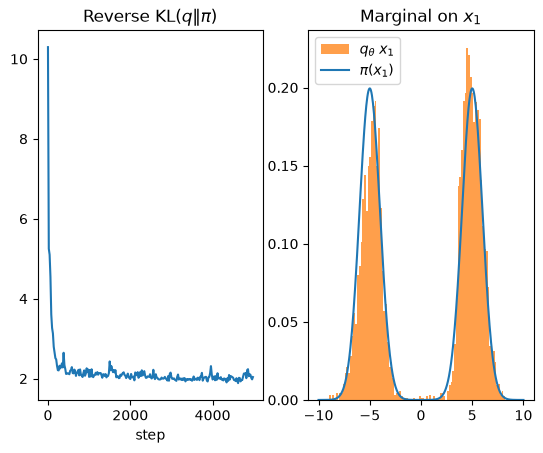

In [36]:
# samples from q_θ and compare x1-marginal to the 1D mixture
key, k_samp = jax.random.split(key)
z_samp = jax.random.normal(k_samp, (5000, 2))
x_samp, _ = flow.apply({"params": params_rkl}, z_samp, reverse=True)
x_samp = np.asarray(x_samp)

xg = np.linspace(-10, 10, 400)
pi_1d = np.asarray(mixture_pdf(jnp.asarray(xg)))

fig, axes = plt.subplots(1, 2)
axes[0].plot(np.arange(0, n_steps, 20), rkl_losses)
axes[0].set_title(r"Reverse KL$(q\|\pi)$")
axes[0].set_xlabel("step")

axes[1].hist(x_samp[:, 0], bins=100, density=True, alpha=0.75, color="tab:orange", label=r"$q_\theta$ $x_1$")
axes[1].plot(xg, pi_1d, color="tab:blue", label=r"$\pi(x_1)$")
axes[1].set_title(r"Marginal on $x_1$")
axes[1].legend()

# quick mode check
frac_pos = float(np.mean(x_samp[:, 0] > 0))
print(f"fraction of samples with x1>0: {frac_pos:.3f} (≈0.5 if both modes covered)")

### PosteriorDB experiments

Use [`posteriordb`](https://github.com/stan-dev/posteriordb) posteriors as realistic sampling targets.

Pipeline (per posterior):
1. Load data + **reference draws**
2. Unnormalized $\log\gamma(\theta)$ from the model (JAX closed form)
3. Train NF with reverse KL against $\gamma$
4. Compare NF samples to reference draws

This notebook uses (both have reference draws):
- `earnings-logearn_height` — 3D $(\beta_1,\beta_2,\sigma)$
- `arma-arma11` — ARMA(1,1), 4D $(\mu,\phi,\theta,\sigma)$

In [41]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# package may live in venv or local vendor/ (sandbox install)
_root = Path.cwd() if (Path.cwd() / "libs").is_dir() else Path.cwd().parent
vendor = _root / "vendor"
if vendor.is_dir():
    sys.path.insert(0, str(vendor))

from posteriordb import PosteriorDatabase

pdb_path = _root / "posteriordb" / "posterior_database"
if not pdb_path.is_dir():
    raise FileNotFoundError(
        f"Missing {pdb_path}. Clone stan-dev/posteriordb or unzip it next to the project root."
    )

pdb = PosteriorDatabase(str(pdb_path.resolve()))
print(f"posteriors in DB: {len(pdb.posterior_names())}")

POSTERIOR_NAMES = [
    "earnings-logearn_height",
    "arma-arma11",
]

def has_reference_draws(posterior):
    try:
        return posterior.reference_draws_info() is not None
    except Exception:
        return False

def reference_draws_matrix(posterior):
    """Stack all chains into an (N, d) array; columns sorted by parameter name."""
    chains = posterior.reference_draws()  # list[dict[str, list]]
    keys = sorted(chains[0].keys())
    cols = [np.concatenate([np.asarray(ch[k], dtype=float) for ch in chains]) for k in keys]
    return np.column_stack(cols), keys

pdb_targets = {}
for name in POSTERIOR_NAMES:
    post = pdb.posterior(name)
    entry = {
        "posterior": post,
        "data": post.data.values(),
        "stan": post.model.code("stan"),
        "has_ref": has_reference_draws(post),
        "X_ref": None,
        "param_names": None,
    }
    if entry["has_ref"]:
        X_ref, param_names = reference_draws_matrix(post)
        entry["X_ref"] = X_ref
        entry["param_names"] = param_names
    pdb_targets[name] = entry

    print(f"\n=== {name} ===")
    print("has reference draws:", entry["has_ref"])
    if entry["has_ref"]:
        print("params:", entry["param_names"], "ref shape:", entry["X_ref"].shape)
    data = entry["data"]
    print("data keys:", list(data.keys()))
    for k, v in data.items():
        a = np.asarray(v)
        if a.size <= 8:
            print(f"  {k}: {v}")
        else:
            print(f"  {k}: shape={a.shape}")
    print("stan (head):\n", entry["stan"][:350], "...")

posteriors in DB: 148

=== earnings-logearn_height ===
has reference draws: True
params: ['beta[1]', 'beta[2]', 'sigma'] ref shape: (10000, 3)
data keys: ['N', 'earn', 'height', 'male']
  N: 1192
  earn: shape=(1192,)
  height: shape=(1192,)
  male: shape=(1192,)
stan (head):
 data {
  int<lower=0> N;
  vector[N] earn;
  vector[N] height;
}
transformed data {
  // log transformation
  vector[N] log_earn;
  log_earn = log(earn);
}
parameters {
  vector[2] beta;
  real<lower=0> sigma;
}
model {
  log_earn ~ normal(beta[1] + beta[2] * height, sigma);
}


 ...

=== arma-arma11 ===
has reference draws: True
params: ['mu', 'phi', 'sigma', 'theta'] ref shape: (10000, 4)
data keys: ['T', 'y']
  T: 200
  y: shape=(200,)
stan (head):
 // ARMA(1, 1)

data {
  int<lower=1> T; // number of observations
  array[T] real y; // observed outputs
}
parameters {
  real mu; // mean coefficient
  real phi; // autoregression coefficient
  real theta; // moving average coefficient
  real<lower=0> sigma; // no

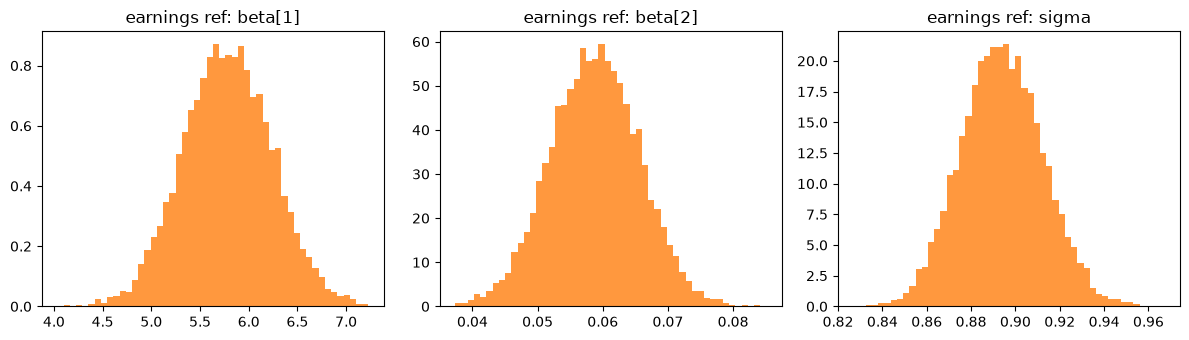

earnings ref mean: [5.7817236  0.05877234 0.89395671]


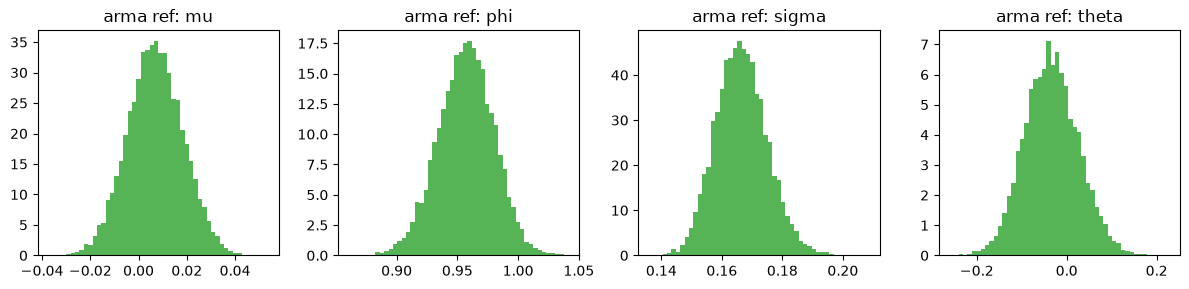

arma params: ['mu', 'phi', 'sigma', 'theta'] mean: [ 0.00691486  0.95701289  0.16648162 -0.03369602]


In [42]:
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm as jax_norm

# --- earnings-logearn_height ---
# Stan: log(earn) ~ normal(beta[1] + beta[2] * height, sigma); flat priors

def earnings_log_gamma(theta, data):
    """theta: (..., 3) = (beta1, beta2, sigma>0)."""
    theta = jnp.atleast_2d(theta)
    beta1, beta2, sigma = theta[..., 0], theta[..., 1], theta[..., 2]
    log_earn = jnp.log(jnp.asarray(data["earn"], dtype=jnp.float32))
    height = jnp.asarray(data["height"], dtype=jnp.float32)
    mu = beta1[..., None] + beta2[..., None] * height[None, :]
    return jnp.sum(jax_norm.logpdf(log_earn[None, :], loc=mu, scale=sigma[..., None]), axis=-1)

def earnings_log_gamma_unconstrained(u, data):
    """u: (..., 3) = (beta1, beta2, raw_sigma); sigma = softplus(raw)+eps."""
    u = jnp.atleast_2d(u)
    beta1, beta2, raw_s = u[..., 0], u[..., 1], u[..., 2]
    sigma = jax.nn.softplus(raw_s) + 1e-4
    theta = jnp.stack([beta1, beta2, sigma], axis=-1)
    # d softplus / d raw = sigmoid(raw)
    return earnings_log_gamma(theta, data) + jax.nn.log_sigmoid(raw_s)

# --- arma-arma11 ---
# DB param order: (mu, phi, sigma, theta_ma)
# IMPORTANT: |phi| or |ma| > 1 makes the AR recursion explode → -inf/NaN.
# Use tanh to keep them in (-1, 1).

def arma_log_gamma(theta, data):
    """theta: (..., 4) = (mu, phi, sigma, theta_ma) with sigma>0."""
    theta = jnp.atleast_2d(theta)
    mu, phi, sigma, ma = theta[..., 0], theta[..., 1], theta[..., 2], theta[..., 3]
    y = jnp.asarray(data["y"], dtype=jnp.float32)
    T = y.shape[0]
    batch = mu.shape[0]
    err = jnp.zeros((batch, T), dtype=y.dtype)
    err = err.at[:, 0].set(y[0] - (mu + phi * mu))

    def body(t, err):
        nu_t = mu + phi * y[t - 1] + ma * err[:, t - 1]
        return err.at[:, t].set(y[t] - nu_t)

    err = jax.lax.fori_loop(1, T, body, err)
    # clip for numerical safety in logpdf (should already be finite if |phi|,|ma|<1)
    err = jnp.clip(err, -1e6, 1e6)
    log_lik = jnp.sum(jax_norm.logpdf(err, loc=0.0, scale=sigma[:, None]), axis=-1)
    log_prior = (
        jax_norm.logpdf(mu, 0.0, 10.0)
        + jax_norm.logpdf(phi, 0.0, 2.0)
        + jax_norm.logpdf(ma, 0.0, 2.0)
        + jax.scipy.stats.cauchy.logpdf(sigma, 0.0, 2.5)
    )
    return log_lik + log_prior

def arma_log_gamma_unconstrained(u, data):
    """u: (..., 4) = (mu, raw_phi, raw_sigma, raw_ma)."""
    u = jnp.atleast_2d(u)
    mu = u[..., 0]
    # keep |phi|,|ma| strictly inside (-1,1) for AR recursion stability
    phi = 0.98 * jnp.tanh(u[..., 1])
    raw_s = u[..., 2]
    ma = 0.98 * jnp.tanh(u[..., 3])
    sigma = jax.nn.softplus(raw_s) + 1e-4
    theta = jnp.stack([mu, phi, sigma, ma], axis=-1)
    log_jac = (
        jnp.log(0.98) + jnp.log1p(-(phi / 0.98) ** 2)
        + jnp.log(0.98) + jnp.log1p(-(ma / 0.98) ** 2)
        + jax.nn.log_sigmoid(raw_s)
    )
    return arma_log_gamma(theta, data) + log_jac

def make_whitened_log_pi(log_pi_fn, ref_mean, ref_std):
    """Train in z-space where θ = mean + std * z (coordinate-wise)."""
    ref_mean = jnp.asarray(ref_mean, dtype=jnp.float32)
    ref_std = jnp.asarray(ref_std, dtype=jnp.float32)

    def log_pi_z(z):
        z = jnp.atleast_2d(z)
        theta = ref_mean + ref_std * z
        # Jacobian of θ(z): prod(std_i)
        return log_pi_fn(theta) + jnp.sum(jnp.log(ref_std))

    return log_pi_z

# --- reference-draw plots ---
earn = pdb_targets["earnings-logearn_height"]
arma = pdb_targets["arma-arma11"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, ax in enumerate(axes):
    ax.hist(earn["X_ref"][:, i], bins=50, density=True, color="tab:orange", alpha=0.8)
    ax.set_title(f"earnings ref: {earn['param_names'][i]}")
plt.tight_layout()
plt.show()
print("earnings ref mean:", earn["X_ref"].mean(0))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.hist(arma["X_ref"][:, i], bins=50, density=True, color="tab:green", alpha=0.8)
    ax.set_title(f"arma ref: {arma['param_names'][i]}")
plt.tight_layout()
plt.show()
print("arma params:", arma["param_names"], "mean:", arma["X_ref"].mean(0))

#### Reverse KL NF on PosteriorDB targets

Unconstrained maps (needed for a Gaussian base + numerical stability):

- **earnings** (3D): $u=(\beta_1,\beta_2,s_{\mathrm{raw}})$, $\sigma=\mathrm{softplus}(s_{\mathrm{raw}})+\varepsilon$
- **arma-arma11** (4D): $u=(\mu,\phi_{\mathrm{raw}},s_{\mathrm{raw}},\theta_{\mathrm{raw}})$ with
  $\phi=\tanh(\phi_{\mathrm{raw}})$, $\theta_{\mathrm{MA}}=\tanh(\theta_{\mathrm{raw}})$, $\sigma=\mathrm{softplus}(s_{\mathrm{raw}})+\varepsilon$
  so $|\phi|,|\theta_{\mathrm{MA}}|<1$ (avoids AR recursion blow-up → NaN loss).

Reuse `train_reverse_kl(...)`.

In [43]:
def inv_softplus(s, eps=1e-4):
    s = np.maximum(s - eps, 1e-6)
    return np.log(np.expm1(s))

def theta_to_u_earnings(theta):
    # theta: (N,3) = beta1, beta2, sigma
    return np.column_stack([theta[:, 0], theta[:, 1], inv_softplus(theta[:, 2])])

def theta_to_u_arma(theta, eps=0.98):
    # theta: (N,4) = mu, phi, sigma, ma
    phi = np.clip(theta[:, 1] / eps, -0.999, 0.999)
    ma = np.clip(theta[:, 3] / eps, -0.999, 0.999)
    return np.column_stack([
        theta[:, 0],
        np.arctanh(phi),
        inv_softplus(theta[:, 2]),
        np.arctanh(ma),
    ])

def u_to_theta_earnings(u):
    return np.column_stack([u[:, 0], u[:, 1], 1e-4 + np.log1p(np.exp(np.clip(u[:, 2], -20, 20)))])

def u_to_theta_arma(u, eps=0.98):
    softplus = lambda x: 1e-4 + np.log1p(np.exp(np.clip(x, -20, 20)))
    return np.column_stack([
        u[:, 0],
        eps * np.tanh(u[:, 1]),
        softplus(u[:, 2]),
        eps * np.tanh(u[:, 3]),
    ])

# Reuse notebook-level train_reverse_kl(...)
pdb_steps = 4000
# lower LR + grad clip: ARMA likelihood is sharp / can explode otherwise
optimizer_pdb = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(3e-4))

# --- earnings (3D), whitened unconstrained coords ---
data_earn = pdb_targets["earnings-logearn_height"]["data"]
U_earn_ref = theta_to_u_earnings(pdb_targets["earnings-logearn_height"]["X_ref"])
earn_mean, earn_std = U_earn_ref.mean(0), U_earn_ref.std(0)
earn_std = np.maximum(earn_std, 1e-6)
log_pi_earn_z = make_whitened_log_pi(
    lambda u: earnings_log_gamma_unconstrained(u, data_earn),
    earn_mean,
    earn_std,
)

flow_earn = NICE(layer_size=3, no_layers=5, hidden_sizes=(64, 64))
key_earn = jax.random.PRNGKey(11)
key_earn, k_init = jax.random.split(key_earn)
params_earn = flow_earn.init(k_init, jnp.zeros((8, 3)))["params"]
params_earn, losses_earn, key_earn = train_reverse_kl(
    log_pi_earn_z, flow_earn, params_earn, optimizer_pdb,
    steps=pdb_steps, seed=11, batch_size=128,
)
print("earnings final loss:", losses_earn[-1], "nan?", bool(np.isnan(losses_earn[-1])))

# --- arma-arma11 (4D), whitened unconstrained coords ---
data_arma = pdb_targets["arma-arma11"]["data"]
U_arma_ref = theta_to_u_arma(pdb_targets["arma-arma11"]["X_ref"])
arma_mean, arma_std = U_arma_ref.mean(0), U_arma_ref.std(0)
arma_std = np.maximum(arma_std, 1e-6)
log_pi_arma_z = make_whitened_log_pi(
    lambda u: arma_log_gamma_unconstrained(u, data_arma),
    arma_mean,
    arma_std,
)

flow_arma = NICE(layer_size=4, no_layers=5, hidden_sizes=(64, 64))
key_arma = jax.random.PRNGKey(12)
key_arma, k_init = jax.random.split(key_arma)
params_arma = flow_arma.init(k_init, jnp.zeros((8, 4)))["params"]
params_arma, losses_arma, key_arma = train_reverse_kl(
    log_pi_arma_z, flow_arma, params_arma, optimizer_pdb,
    steps=pdb_steps, seed=12, batch_size=64,
)
print("arma final loss:", losses_arma[-1], "nan?", bool(np.isnan(losses_arma[-1])))


reverse KL: 100%|█| 4


earnings final loss: 1568.27978515625 nan? False


reverse KL: 100%|█| 4

arma final loss: -52.68087387084961 nan? False


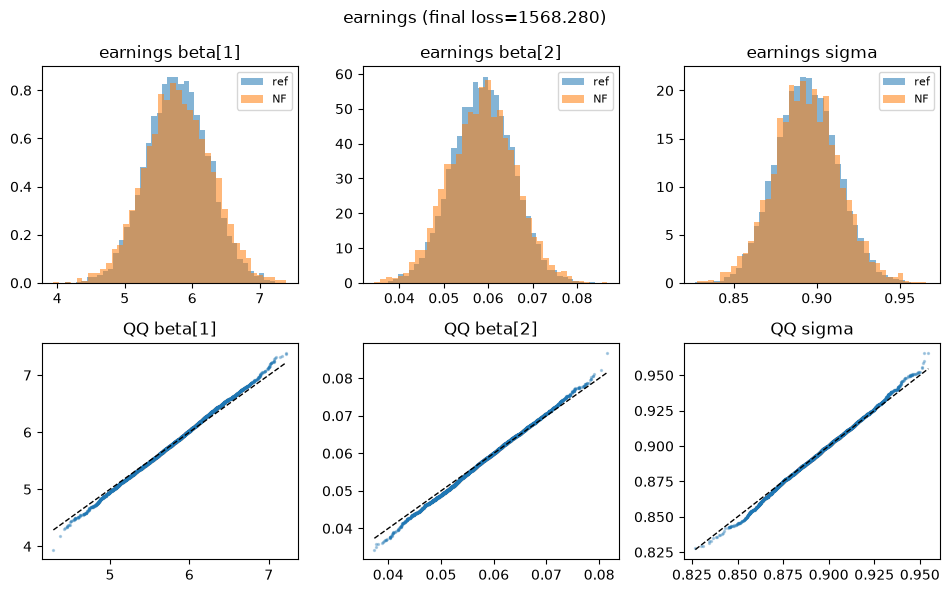

earnings ref mean [5.7817236  0.05877234 0.89395671] | NF mean [5.79504678 0.05860796 0.89385405]


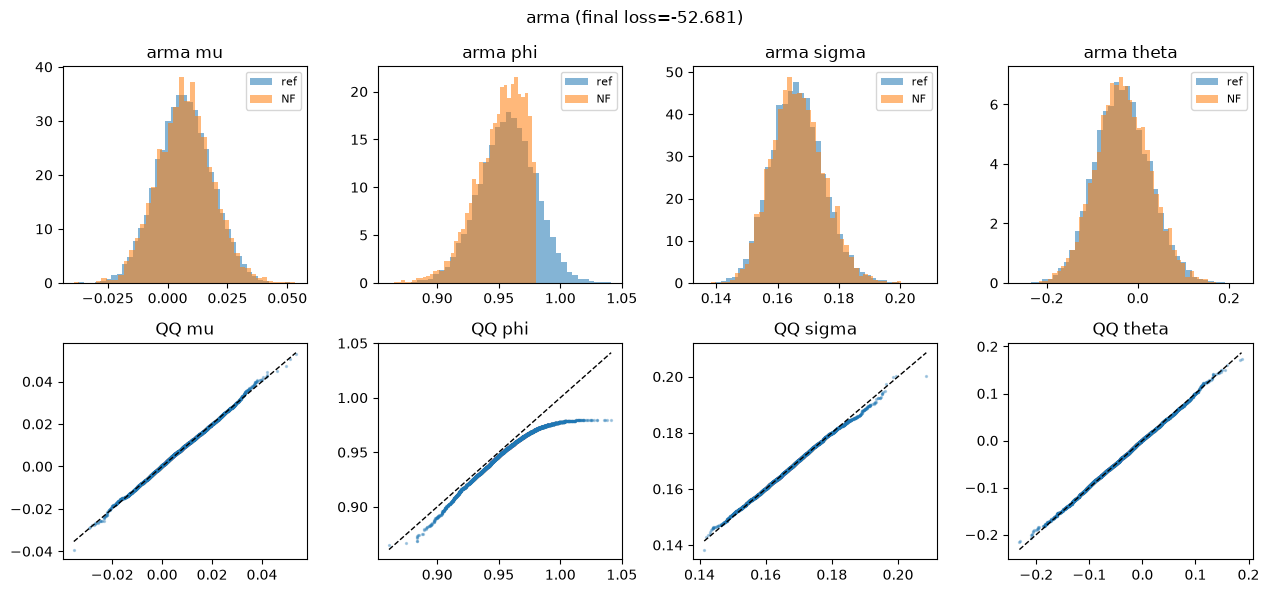

arma ref mean [ 0.00691486  0.95701289  0.16648162 -0.03369602] | NF mean [ 0.00716032  0.95058928  0.16661176 -0.03256917]


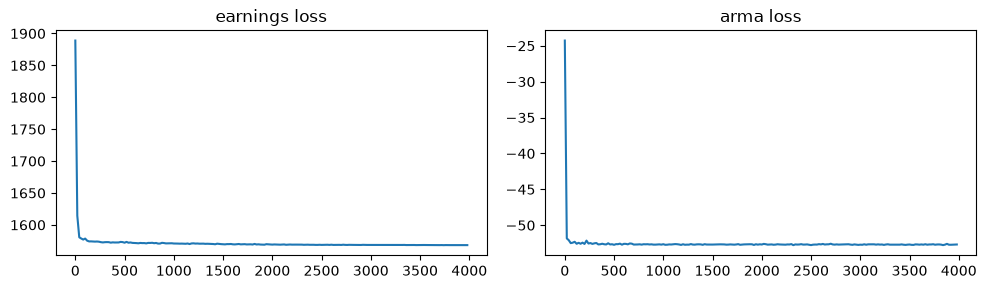

In [44]:
def sample_flow(flow, params, key, n=5000):
    dim = flow.layer_size
    key, k = jax.random.split(key)
    z = jax.random.normal(k, (n, dim))
    x, _ = flow.apply({"params": params}, z, reverse=True)
    return np.asarray(x), key

def plot_compare(losses, theta_nf, theta_ref, param_names, title_prefix):
    d = theta_ref.shape[1]
    fig, axes = plt.subplots(2, d, figsize=(3.2 * d, 6))
    axes = np.atleast_2d(axes)
    for i in range(d):
        axes[0, i].hist(theta_ref[:, i], bins=40, density=True, alpha=0.55, label="ref")
        axes[0, i].hist(theta_nf[:, i], bins=40, density=True, alpha=0.55, label="NF")
        axes[0, i].set_title(f"{title_prefix} {param_names[i]}")
        axes[0, i].legend(fontsize=8)
        ref_q = np.sort(theta_ref[: len(theta_nf), i])
        nf_q = np.sort(theta_nf[:, i])
        axes[1, i].scatter(ref_q, nf_q, s=2, alpha=0.3)
        lo, hi = float(ref_q.min()), float(ref_q.max())
        axes[1, i].plot([lo, hi], [lo, hi], "k--", lw=1)
        axes[1, i].set_title(f"QQ {param_names[i]}")
    fig.suptitle(f"{title_prefix} (final loss={losses[-1]:.3f})")
    plt.tight_layout()
    plt.show()
    print(title_prefix, "ref mean", theta_ref.mean(0), "| NF mean", theta_nf.mean(0))

# flow samples in whitened unconstrained space -> unconstrained u -> theta
z_e, key_earn = sample_flow(flow_earn, params_earn, key_earn)
u_e = earn_mean + earn_std * z_e
plot_compare(
    losses_earn,
    u_to_theta_earnings(u_e),
    pdb_targets["earnings-logearn_height"]["X_ref"],
    pdb_targets["earnings-logearn_height"]["param_names"],
    "earnings",
)

z_a, key_arma = sample_flow(flow_arma, params_arma, key_arma)
u_a = arma_mean + arma_std * z_a
plot_compare(
    losses_arma,
    u_to_theta_arma(u_a),
    pdb_targets["arma-arma11"]["X_ref"],
    pdb_targets["arma-arma11"]["param_names"],
    "arma",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(np.arange(0, pdb_steps, 20), losses_earn)
axes[0].set_title("earnings loss")
axes[1].plot(np.arange(0, pdb_steps, 20), losses_arma)
axes[1].set_title("arma loss")
plt.tight_layout()
plt.show()
